In [29]:
from pathlib import Path
import pandas as pd
import numpy as np
import scanpy as sc
import squidpy as sq
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append('../../scripts')

import readwrite
cfg = readwrite.config()

def concat_samples(ads, correction_method, segmentation, condition=None, panel=None):
    ads_corr_method = ads[correction_method]

    def is_match(key):
        return (
            segmentation in key and
            (condition is None or condition in key) and
            (panel is None or panel in key)
        )

    adata = sc.concat({k: v for k, v in ads_corr_method.items() if is_match(k)},label='dataset_id', join='outer')
    adata.obs[xenium_levels] = pd.DataFrame(adata.obs['dataset_id'].tolist(),index=adata.obs.index,columns=xenium_levels)
    return adata

### Read all xenium samples

In [89]:
# input params
correction_method = 'raw'
segmentation = 'proseg_expected'
condition = 'CRC'
panel = 'hImmune_v1_mm'

xenium_dir = Path(cfg['xenium_processed_dir'])
xenium_count_correction_dir = Path(cfg['xenium_count_correction_dir'])
xenium_std_seurat_analysis_dir = Path(cfg['xenium_std_seurat_analysis_dir'])
xenium_cell_type_annotation_dir = Path(cfg['xenium_cell_type_annotation_dir'])
results_dir = Path(cfg['results_dir'])

xenium_levels = ['segmentation','condition','panel','donor','sample']
normalisation = 'lognorm'
reference = 'GEO_GSE178341'
method = 'rctd_class_aware'
level = 'Level1'


# fixed params
BATCH_KEY = 'dataset_id'
SPATIAL_KEY = 'spatial'
N_CLUSTERS_RANGE = (5,19)
MAX_RUNS = 10
CONVERGENCE_TOL = 0.001
OUTPUT_LABELS = results_dir/'xenium/cellcharter/labels.parquet'
OUTPUT_SCVI_MODEL = results_dir/'xenium/cellcharter/scvi_model'
OUTPUT_CELLCHARTER_MODELS = results_dir/'xenium/cellcharter/cellcharter_models'
OUTPUT_PLOT = results_dir/'xenium/cellcharter/autok_stability.png'

segmentations_filter=[segmentation]
conditions_filter=[condition] if condition is not None else None
panels_filter=[panel] if panel is not None else None

# read samples
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,
    correction_methods_filter=[correction_method],
    # segmentations_filter=[segmentation],
    # conditions_filter=conditions_filter,
    # panels_filter=panels_filter
)


# set transcripts=True to load individual transcripts positions)
if correction_method != 'raw':
    ads = readwrite.read_count_correction_samples(xenium_paths,[correction_method])
else:
    ads = {}
    ads['raw'] = readwrite.read_xenium_samples(
        xenium_paths['raw'],  
        anndata=True, 
        pool_mode="thread",
        max_workers=6
    )

# add cell type annotation from raw to all correction methods
readwrite.read_annotations(ads, correction_method, xenium_annot_paths, level, max_workers=8)

# concat samples
adata = sc.concat({k: v for k, v in ads[correction_method].items() },label='dataset_id', join='inner')
adata.obs[xenium_levels] = pd.DataFrame(adata.obs['dataset_id'].tolist(),index=adata.obs.index,columns=xenium_levels)
adata.obs['correction_method'] = correction_method

# info about the loaded cohort
df_cohort_info = pd.DataFrame([k+(corr_method,) for corr_method in [correction_method] for k in ads[corr_method].keys() ], columns=xenium_levels+['correction_method'])

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdat

INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_5um/CRC/
         hImmune_v1_mm/OIYM/HCC_output-XETG00209__0003786__OIYM__20250503__073331/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             
INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_5um/CRC/
         hImmune_v1_mm/1EGQ/output-XETG00059__0053261__1EGQ__20250306__164822/normalised_results/outs/cell_feature_
         matrix.h5                                                                                                 


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdat

INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_5um/CRC/
         hImmune_v1_mm/14V5/output-XETG00059__0053259__14V5__20250306__164822/normalised_results/outs/cell_feature_
         matrix.h5                                                                                                 


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata_io/_utils.py:47: UserWarning: The "cell_id" column in the cells metadata table does not match the "cell_id" column in the annotation table. This could be due to trying to read a new version that is not supported yet. Please report this issue.
  return f(*args, **kwargs)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str inde

...

INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_0um/CRC_
         PDO/hImmune_v1_mm/1GAA/output-XETG00059__0021741__1GAA__20250319__172035/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             
INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_0um/CRC_
         PDO/hImmune_v1_mm/OWMY/output-XETG00059__0021741__OWMY__20250319__172035/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata_io/_utils.py:47: UserWarning: The "cell_id" column in the cells metadata table does not match the "cell_id" column in the annotation table. This could be due to trying to read a new version that is not supported yet. Please report this issue.
  return f(*args, **kwargs)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/sit

INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_0um/CRC_
         PDO/hImmune_v1_mm/OUC1/output-XETG00059__0021738__OUC1__20250319__172035/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             
INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_0um/CRC_
         PDO/hImmune_v1_mm/OAFN/output-XETG00059__0021738__OAFN__20250319__172035/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             
INFO     reading                                                        

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata_io/_utils.py:47: UserWarning: The "cell_id" column in the cells metadata table does not match the "cell_id" column in the annotation table. This could be due to trying to read a new version that is not supported yet. Please report this issue.
  return f(*args, **kwargs)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata_io/_utils.py:47: UserWarning: The "cell_id" column in the cells metadata table does not match the "cell_id" column in the annotation table. This could be due to trying to read a new version that is

KeyError: 'r'

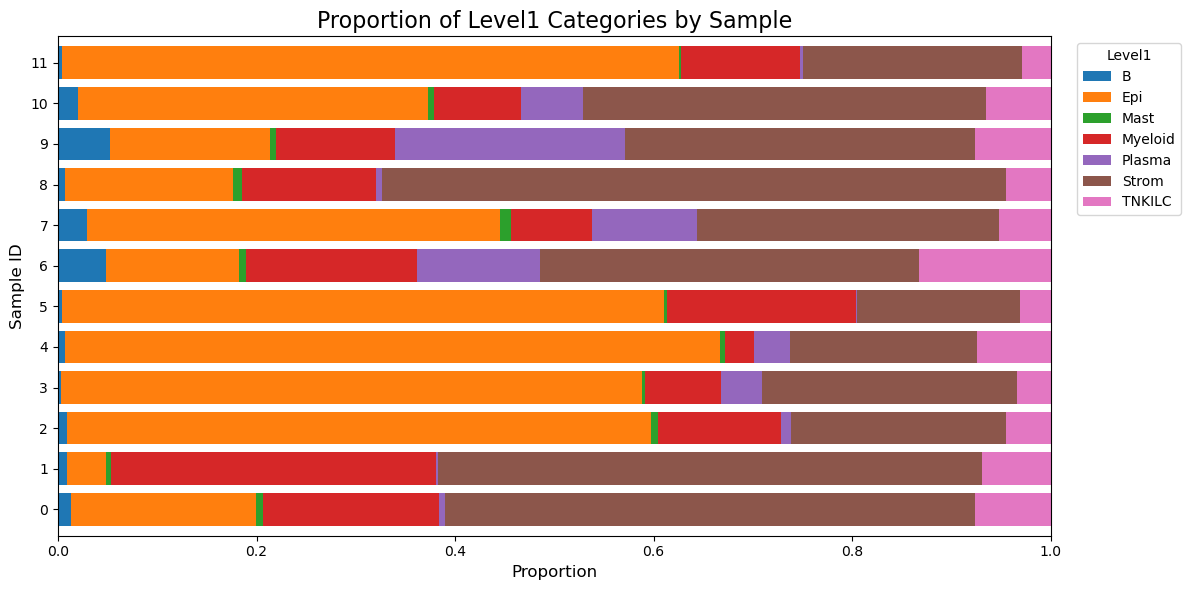

In [88]:
df_props = (
    adata.obs
    .groupby(xenium_levels)['Level1']
    .value_counts(normalize=True)
    .unstack()
    .reset_index()
)
df_props['full_sample_id'] = df_props[xenium_levels].astype(str).agg(' | '.join, axis=1)

# Step 2: Dynamically set the figure size
num_samples = len(df_props.index)
fig_height = max(6, num_samples * 0.4) 

# Step 3: Create the figure and axes object
fig, ax = plt.subplots(figsize=(12, fig_height))

# Step 4: Plot directly onto the created axes object
df_props.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    width=0.8
)


# Step 6: Customize the plot
ax.set_title('Proportion of Level1 Categories by Sample', fontsize=16)
ax.set_xlabel('Proportion', fontsize=12)
ax.set_ylabel('Sample ID', fontsize=12)
# ax.set_yticklabels(df_props['full_sample_id'])
ax.legend(title='Level1', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()